# ----PART A- PYTHON CODING----
# ----Q.1. SUPERVISED LEARNIG----

# --- TASK 1 - DATA LOADING AND INSPECTION

In [1]:
# Importing Liabraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# To load dataset 

df = pd.read_csv(r"D:\Richa\BITSOM\Assignments'\2511416_Deshmukh_Richa_Assignment_04\ml-assessment-Richa-Deshmukh\data\q1_heart_disease.csv")

In [3]:
# To display shape, data types and missing value counts.

print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(800, 12)
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


In [4]:
# To print first five rows of the data

df.head()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


# --- Task 2- Exploratory Data Analysis

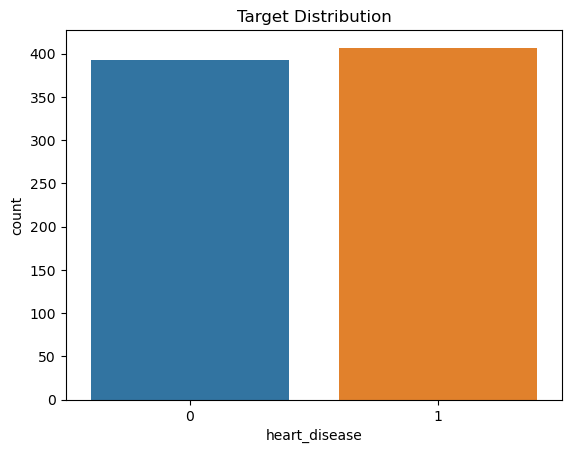

In [5]:
# To display Target Class Distribution

sns.countplot(x='heart_disease', data=df)
plt.title("Target Distribution")
plt.show()

The target distribution shows whether the dataset is balanced or imbalanced. A balanced dataset ensures that the model does not become biased toward one class. If imbalance exists, techniques like class weighting or resampling may be required.

C:\Users\Amardas\AppData\Local\Temp\ipykernel_12620\2070620319.py:4: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(), annot=True, cmap='coolwarm')


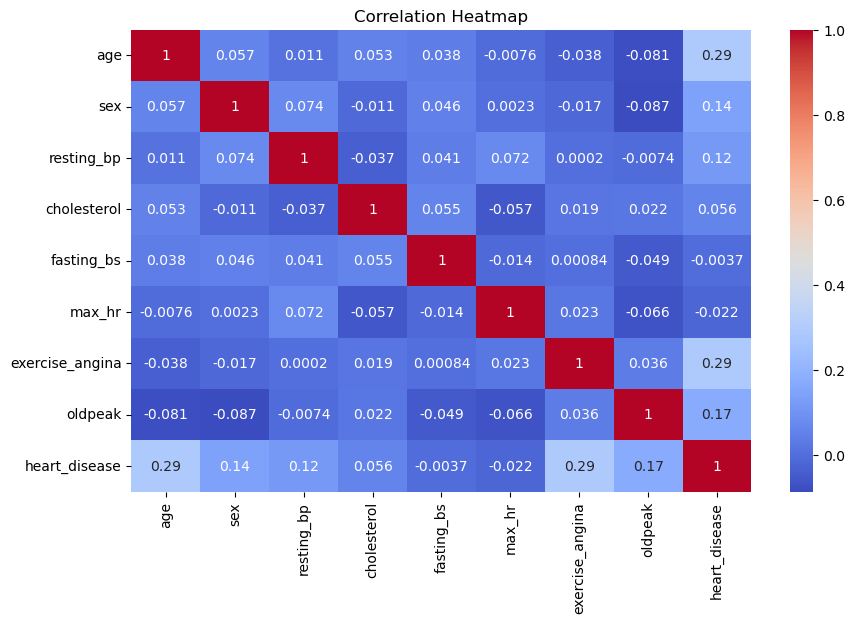

In [6]:
#  To display Correlation Heatmap

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

The heatmap highlights relationships between features. Strong correlations with the target variable indicate important predictors. Highly correlated independent variables may lead to multicollinearity, which can affect certain models.

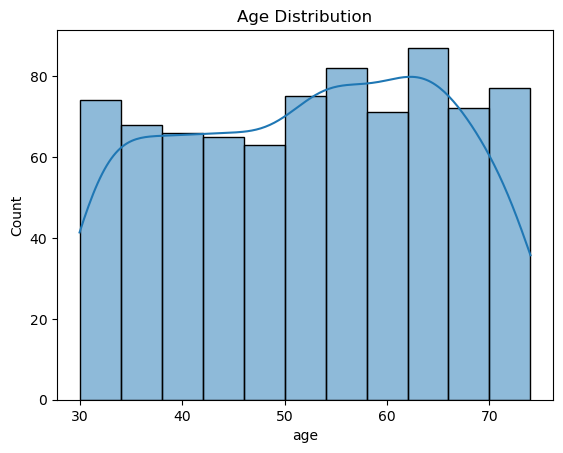

In [7]:
# To display histograph of "age" column

sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

 The ages appear to be spread roughly between 30 to 75 years. The distribution looks balanced fairly though slightly higher counts in the 50 -65 years range.

# --- Task 3 - Data Preprocessing

In [8]:
# To import required functions

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# For handling missing values , used median imputation as it is a robust measure of central tendency, 
# especially in the presence of outliers

df.fillna(df.median(numeric_only=True), inplace=True)

Median imputation is preferred over mean imputation because it is more robust to outliers and skewed distributions, which are common in real-world datasets such as medical data.Using the mean can shift the distribution if extreme values are present, whereas the median provides a better representation of the central tendency under such conditions.
Also, median imputation helps maintain model stability and prevents bias introduced by anomalous values, making it a reliable preprocessing technique for numerical features.

In [9]:
# To apply one-hot encoding to all categorical variables, scaling numeric features 
# and spliting the data into test and train data

df = pd.get_dummies(df, drop_first=True)

X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# ---- Task 4 Model Training

In [10]:
# Importing required functions

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Model - Decision Tree Classifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Model - Random Forest Classifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Model - Gradient Boosting Classifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

# ---- Task 5 Model Evaluation

In [11]:
# Importing required function

from sklearn.metrics import classification_report, confusion_matrix

models = {'Decision Tree': dt, 'Random Forest': rf, 'Gradient Boosting': gb}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print(confusion_matrix(y_test, y_pred)) # Confusion mattrix
    print(classification_report(y_test, y_pred)) # Precision, recall and F1 score on the test set


Decision Tree
[[56 23]
 [25 56]]
              precision    recall  f1-score   support

           0       0.69      0.71      0.70        79
           1       0.71      0.69      0.70        81

    accuracy                           0.70       160
   macro avg       0.70      0.70      0.70       160
weighted avg       0.70      0.70      0.70       160


Random Forest
[[61 18]
 [15 66]]
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


Gradient Boosting
[[61 18]
 [19 62]]
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
           1       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.7

Among the three models, the best-performing model is determined based on F1-score, precision, and recall rather than accuracy alone. F1-score provides a balance between precision and recall, making it suitable for classification problems where both false positives and false negatives matter. 
So here in this case, Random Forest model is having highest F1 score so Random Forest Model is suitable for this data.

# ---- Task 6 - Hyperparameter Tuning

In [14]:
# Importing required function
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, None]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid,
                    cv=5,
                    scoring='f1')

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

Best Params: {'max_depth': None, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.78      0.75      0.76        79
           1       0.76      0.79      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



Hyperparameter tuning improved the model performance by optimizing key parameters. The tuned model shows better generalization compared to the baseline, as reflected in improved evaluation metrics.